# Notebook 4

This is a notebook to test ABP and ABF on a simple one dimensional case with potential $V(x) = (1 - x^2)^2$

## Section 1

Calculate transition times simulating the whole process, also histograms

Transition detected at index: 452, time: 4.5200000000000005


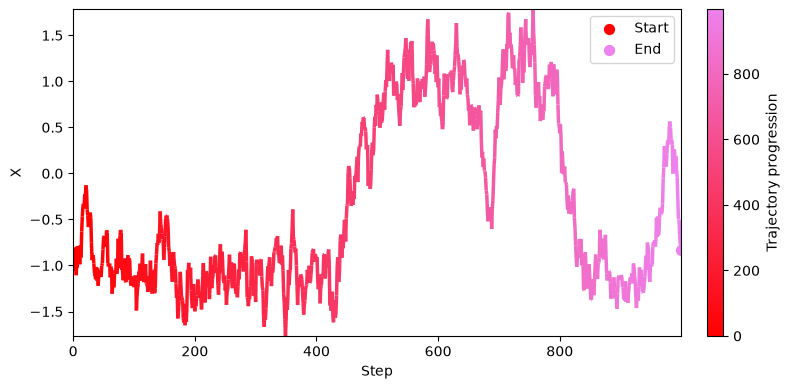

In [1]:
import numpy as np
from src.abp_abf.potential import Potential
from src.abp_abf.transition_detector import TransitionDetector
from src.brownian import BrownianMotion


dt = 0.01
potential = Potential(1, lambda x: (1 - x[0] ** 2) ** 2, lambda x: -4 * x[0] * (1 - x[0] ** 2))
bm = BrownianMotion(num_steps=1000, delta_t=dt, dimension=1, D=1, initial_position=np.array([-1.0]), b=lambda x: -potential.potential_prime_at(x))
bm.simulate()

td = TransitionDetector(bm.positions, lambda x: x[0], 0.0)
transition_index = td.detect_transition()
transition_time = transition_index * dt if transition_index is not None else None

print(f"Transition detected at index: {transition_index}, time: {transition_time}")
bm.plot_brownian_path(bm.positions, mode_1d="time_series", point_stride=10000)

In [7]:
import numpy as np
from src.abp_abf.potential import Potential
from src.abp_abf.transition_detector import TransitionDetector
from src.brownian import BrownianMotion
from src.statistics import Statistics
from joblib import Parallel, delayed


def run_one_simulation():
    dt = 0.0001
    potential = Potential(1, lambda x: (1 - x[0] ** 2) ** 2, lambda x: -4 * x[0] * (1 - x[0] ** 2))


    bm = BrownianMotion(num_steps=10000, delta_t=dt, dimension=1, D=1, initial_position=np.array([-1.0]), b=lambda x: -potential.potential_prime_at(x))
    bm.simulate()

    td = TransitionDetector(bm.positions, lambda x: x[0], 0.0)
    transition_index = td.detect_transition()
    transition_time = transition_index * dt if transition_index is not None else None
    return transition_time

Mean transition time: 0.49754504021447726
Standard deviation of transition times: 0.25917989809364766


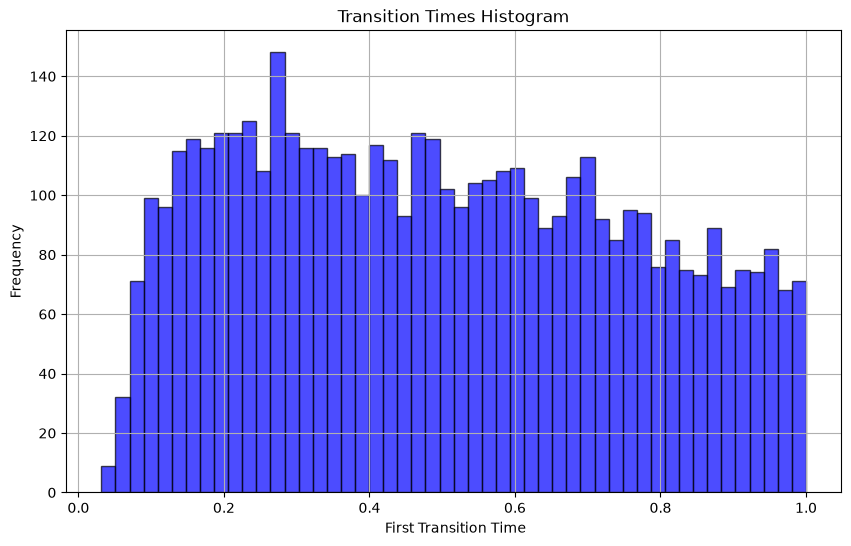

In [8]:
transition_times = []
exit_points = []

results = Parallel(n_jobs=-1)(
    delayed(run_one_simulation)()
    for _ in range(10000)
)

for transition_time in results:
    if transition_time is not None:
        transition_times.append(transition_time)

transition_times = np.array(transition_times)

mean_transition_time = np.mean(transition_times)

dev_transition_time = np.std(transition_times)

print(f"Mean transition time: {mean_transition_time}")
print(f"Standard deviation of transition times: {dev_transition_time}")
Statistics.plot_histogram(transition_times, bins=50, title="Transition Times Histogram", xlabel=" First Transition Time", ylabel="Frequency")